In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

In [5]:
X.sample(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
18449,6.3178,19.0,6.426829,1.041463,1497.0,3.651220,37.23,-121.81
15613,3.5227,19.0,5.401222,1.059063,1421.0,2.894094,32.61,-116.79
10019,2.4688,16.0,4.789969,1.100313,729.0,2.285266,39.19,-121.18
9615,1.9535,11.0,4.613941,1.021448,1708.0,4.579088,37.28,-120.49
15134,2.8875,17.0,5.676538,1.125285,1278.0,2.911162,32.82,-116.92
6890,3.7560,31.0,4.977622,1.026573,2975.0,4.160839,34.05,-118.10
20511,2.0368,40.0,4.568966,1.086207,1304.0,2.810345,38.59,-121.54
19748,4.2917,17.0,5.482014,0.992806,322.0,2.316547,40.20,-122.23
19025,4.2137,13.0,5.153724,0.966719,1915.0,3.034865,38.34,-121.99
3397,3.0583,41.0,4.117460,1.038095,733.0,2.326984,34.26,-118.31


In [6]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [11]:
X.isnull().sum()
X.isnull().value_counts()

MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
False   False     False     False      False       False     False     False        20640
Name: count, dtype: int64

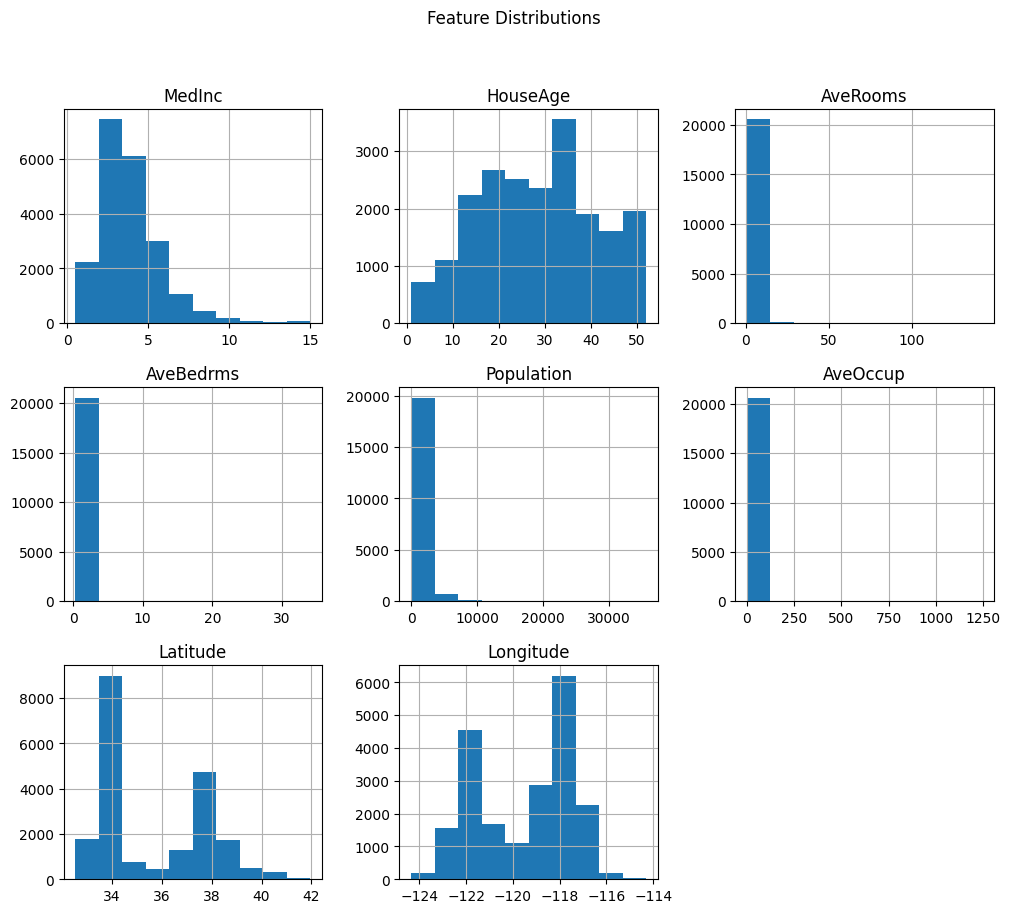

In [13]:
X.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

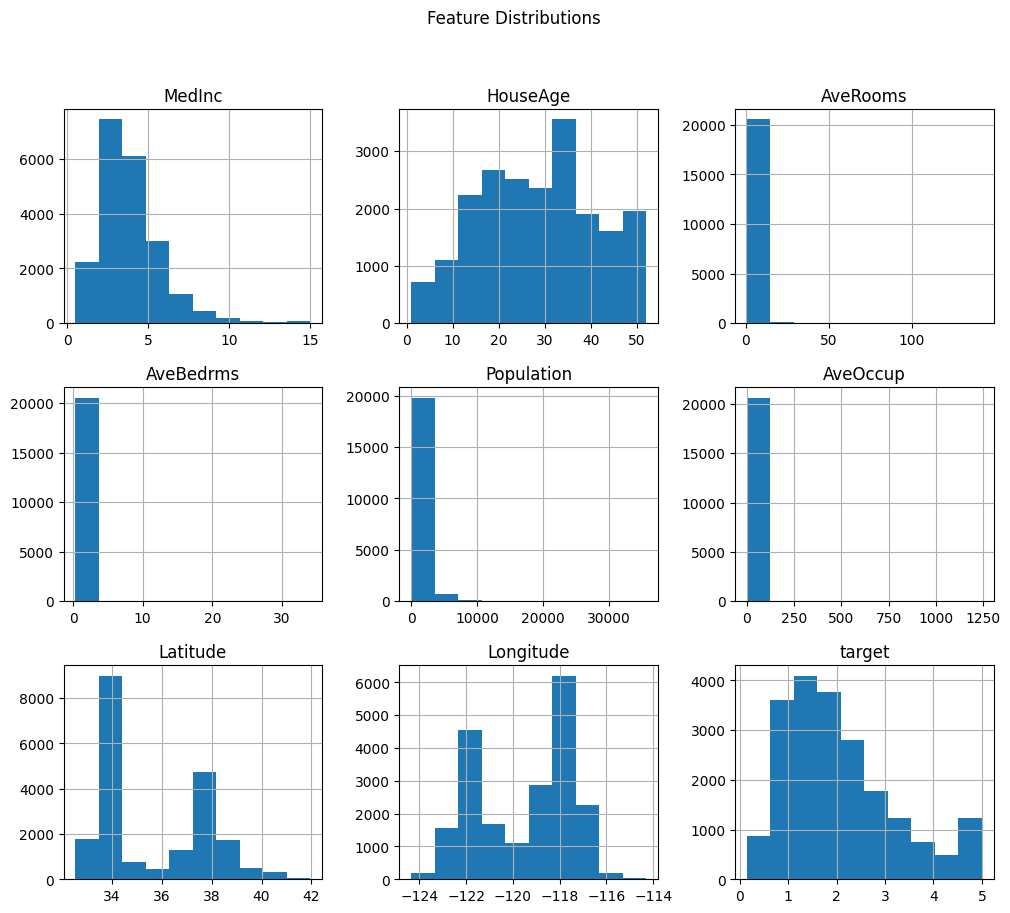

In [15]:
all_df=X.copy()
all_df['target']=y
all_df.head()
all_df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = LinearRegression()


In [19]:
model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [39]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")
accuracy = r2 * 100
print("Model Accuracy (R² × 100): {:.2f}%".format(accuracy))

Mean Squared Error: 0.6713632829708934
Mean Absolute Error: 0.6119930525394647
R-squared: 0.4876688925986029
Model Accuracy (R² × 100): 48.77%


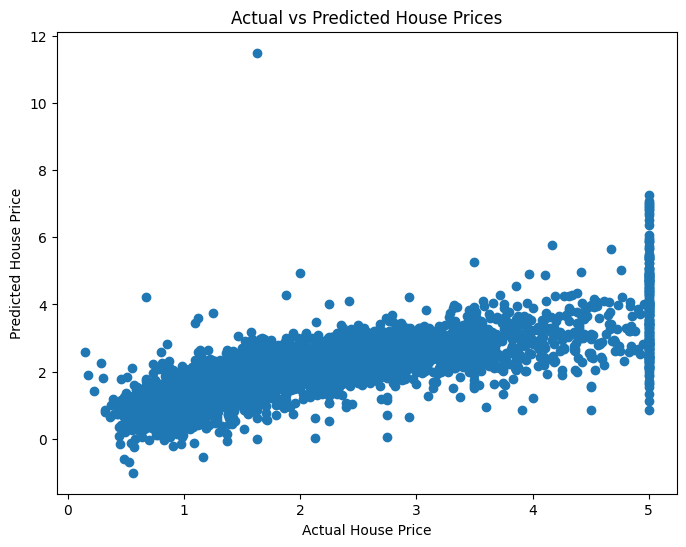

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

After apply PCA 

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
from sklearn.decomposition import PCA

In [28]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nOriginal Features :", X_train.shape[1])
print("Reduced Features  :", X_train_pca.shape[1])

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:",
      sum(pca.explained_variance_ratio_))


Original Features : 8
Reduced Features  : 6

Explained Variance Ratio:
[0.25313826 0.23403182 0.15917174 0.12976895 0.12547205 0.08216517]

Total Explained Variance: 0.98374798175326


In [29]:
model = LinearRegression()
model.fit(X_train_pca, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test_pca)

In [34]:
mse_pca = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse_pca}")
mae_pca = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae_pca}")
r2_pca = r2_score(y_test, y_pred)
print(f"R-squared: {r2_pca}")

Mean Squared Error: 0.6713632829708934
Mean Absolute Error: 0.6119930525394647
R-squared: 0.4876688925986029


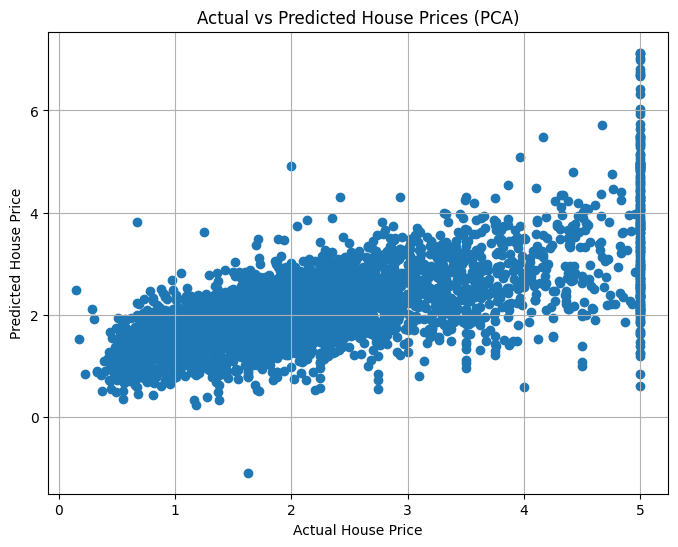

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices (PCA)")
plt.grid(True)
plt.show()

In [36]:
print("Model Accuracy (R² × 100): {:.2f}%".format(r2_pca * 100))

Model Accuracy (R² × 100): 48.77%
